# Fitting a Poisson Periodic GP

This notebook fits a Poisson Periodic GP to the spontaneous activity of all cells in the dataset.

In [19]:
base_save_dir = 'results/gen_pois_no_exp/'

In [ ]:
# Autoreloading of modules and files without restarting notebook.
%reload_ext autoreload
%autoreload 2


import os
import pyro
import json
import torch
import pickle
import pandas as pd
from quantities import s
import matplotlib.pyplot as plt
from matplotlib.axes import Axes


from rvm_analysis.colours import get_cell_colour
from rvm_analysis.converters import combine_neutral_and_save
from rvm_analysis.utils import get_cell_colour
from rvm_analysis.non_poisson_gpytorch_model import evaluate_model, compare_log_liks
from rvm_analysis.utils import bin_spikes_and_split
from rvm_analysis.non_poisson_gpytorch_model import nonlinearity, train_model
from rvm_analysis.non_poisson_gpytorch_model import create_mean_model,create_model, save_model_params, get_summary_parameters_and_fits
from rvm_analysis.non_poisson_gpytorch_model import set_mean_and_scale

from rvm_analysis.plotting import plot_rainclouds
from rvm_analysis.plotting import plot_interactive_raincloud



# Set random seed
torch.manual_seed(0)
pyro.set_rng_seed(0)
torch.set_default_dtype(torch.float64)

#! Force the backend back to matplotlib inline (after importing viziphant).
print(plt.get_backend())
%matplotlib inline


module://matplotlib_inline.backend_inline


## Import the data and bin spikes

In [21]:
with open("../../../CUT_CELL_ACTIVITIES.pkl", "rb") as file:
    cut_spikes_ON, cut_spikes_OFF, spikes_NEUTRAL, spikes_NEUTRAL_extra = pickle.load(file)

cut_time = 1200*s
bin_width = 5 *s
data = {
    "ON": bin_spikes_and_split(cut_spikes_ON,bin_width,cut_time),
    "OFF": bin_spikes_and_split(cut_spikes_OFF,bin_width,cut_time),
    "NEUTRAL": bin_spikes_and_split(spikes_NEUTRAL,bin_width,660*s),
    "NEUTRAL_EXTRA": bin_spikes_and_split(spikes_NEUTRAL_extra,bin_width,1200*s),
    }

In [22]:
scale = torch.tensor(10.0)

In [23]:
softplus = torch.nn.Softplus(beta=1,threshold=20)
link_function = nonlinearity(softplus)

## Train the GP on the activities of each cell individually

In [24]:
def plot_training_results(train_x, train_y, test_x, test_y,
                          latent_test_func_quantiles, latent_train_func_quantiles,
                          cell_name, index,quantiles_with_noise,quantiles_with_noise_training,
                          fontsize=12):
    """
    Plots the training results for a cell over test and training data.

    Parameters:
    - train_x, train_y: training data
    - test_x, test_y: test data
    - latent_percentiles: (lower, mean, upper) for test predictions
    - latent_training_percentiles: (lower, mean, upper) for train predictions
    - y_sim: sample from the model (unused now)
    - cell_name, index: identifiers for the plot (unused here)
    - fontsize: unified font size for labels and legend
    """
    lower, mean, upper = latent_test_func_quantiles
    lower_train, mean_train, upper_train = latent_train_func_quantiles
    lower_poisson_test, mean_poisson_test, upper_poisson_test = quantiles_with_noise
    lower_poisson_train, mean_poisson_train, upper_poisson_train = quantiles_with_noise_training

    fig, ax = plt.subplots(figsize=(25, 3))
    ax: Axes
    # GP predictions with uncertainty for test data
    ax.plot(test_x, mean, label='GP f(x) prediction', color='purple')
    ax.plot(test_x, mean_poisson_test, label='GP Likelihood test prediction', color='red')
    ax.plot(train_x, mean_poisson_train, label='GP Likelihood train prediction', color='blue')
    ax.fill_between(
        test_x,
        lower,
        upper,
        color='brown', alpha=0.4
    )

    # GP predictions with uncertainty for train data
    ax.plot(train_x, mean_train, label='GP train prediction', color='green')
    ax.fill_between(
        train_x,
        lower_train,
        upper_train,
        color='brown', alpha=0.4
    )

    ax.fill_between(
        test_x,
        lower_poisson_test,
        upper_poisson_test,
        color='gray', alpha=0.2
    )

    ax.fill_between(
        train_x,
        lower_poisson_train,
        upper_poisson_train,
        color='gray', alpha=0.2
    )

    # True functions
    ax.scatter(test_x, test_y, label='True test function', alpha=0.5, color='black')
    ax.scatter(train_x, train_y, label='True train data', alpha=0.5, color=get_cell_colour(names=cell_name))

    # Style adjustments
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.tick_params(labelsize=fontsize)
    ax.legend(fontsize=fontsize)
    ax.set_xlabel("Time(s)", fontsize=fontsize)
    ax.set_ylabel("Spike Count", fontsize=fontsize)
    ax.grid(False)

    plt.show()

In [ ]:
def fit_all_cells_and_return_params_fits(data, base_save_dir, num_iter,
                                         num_inducing, from_loaded=True,
                                         save_params=False,save_results=False,from_last=True,max_count=100,lr=0.1,cell_ids: list=None,
                                         compare_mean=True,model_mean=False,retrain_mean=False):
    """
    Fit a Poisson GP model for each cell and save R², key params, and full model param store.
    """

    # Create save directory and structures
    os.makedirs(f"{base_save_dir}/saved_models", exist_ok=True)
    summary_list = []
    loss_histories = {}


    # Iterate over each type of cell (ON, OFF, NEUTRAL)
    for (cell_name, cell_data) in data.items():
        train_ys, test_ys, train_x, test_x = cell_data
        test_x = torch.from_numpy(test_x).float()
        train_x = torch.from_numpy(train_x).float()
        T_max = torch.max(train_x)

        # Iterate over each individual cell
        for i, (train_y, test_y) in enumerate(zip(train_ys, test_ys)):
            model_id = f"{cell_name}_{i}"

            if cell_ids is not None:
                if model_id not in cell_ids:
                    continue

            print(model_id)
            model_param_path = os.path.join(base_save_dir, "saved_models", f"{model_id}_model_params.pt")
            mean_model_param_path = os.path.join(base_save_dir, "saved_models", f"{model_id}_mean_model_params.pt")
            lik_param_path = os.path.join(base_save_dir, "saved_models", f"{model_id}_likelihood_params.pt")
            mean_lik_param_path = os.path.join(base_save_dir, "saved_models", f"{model_id}_mean_likelihood_params.pt")

            if from_last:
                if os.path.exists(
                    os.path.join(base_save_dir,"saved_models",f"{model_id}_model_params.pt")
                    ):
                    continue

            
            train_y = torch.from_numpy(train_y).float()
            test_y = torch.from_numpy(test_y).float()

            model, likelihood, mll = create_model(T_min = 0 ,T_max=T_max, max_count=max_count,
                                                  link_function=link_function,link_function_scale=scale,
                                                  num_data = train_y.size(0),num_inducing=num_inducing,
                                                  model_mean=model_mean)
            

            print("alpha_init: ",likelihood.alpha.item(),"output_scale_init: ", model.main_scale)
            set_mean_and_scale(model,likelihood,scale,train_y,has_scale=True)


            # Train the model if not loading
            if from_loaded:
                if not os.path.exists(model_param_path):
                    raise FileNotFoundError(f"Saved model not found at {model_param_path}")
                model.load_state_dict(torch.load(model_param_path))
                likelihood.load_state_dict(torch.load(lik_param_path))
            else:
                
                loss_history = train_model(model,likelihood,mll,train_x,train_y,training_iterations=num_iter,lr=lr,mean_model=False)
                loss_histories[model_id] = loss_history

                save_model_params(model,likelihood,model_param_path,lik_param_path,save=save_params)
            


            latent_percents,quantiles_with_noise,latent_percents_train,quantiles_with_noise_training = evaluate_model(
                model,link_function,scale,likelihood,test_x,train_x,test_y,train_y,i,cell_name=cell_name,model_mean=model_mean)


            plot_training_results(
                train_x, train_y, test_x, test_y,
                latent_percents,
                latent_percents_train,
                cell_name,i, quantiles_with_noise
                ,quantiles_with_noise_training,fontsize=12,
            )

            results=None
            if compare_mean:
                # alpha_emp = 1.0 - torch.sqrt(torch.mean(train_y)/torch.var(train_y))
                #create the mean model
                mean_model, mean_lik, mean_mll = create_mean_model(T_max,max_count=train_y.max(),
                                                                   link_function=link_function,link_function_scale=scale,
                                                                   num_data=train_y.size(0),
                                                                   num_inducing=num_inducing, model_mean=model_mean)
                set_mean_and_scale(mean_model,mean_lik,scale,train_y,has_scale=False)
                if from_loaded and not retrain_mean:
                    mean_model.load_state_dict(torch.load(mean_model_param_path))
                    mean_lik.load_state_dict(torch.load(mean_lik_param_path),strict=False)
                else:
                    mean_loss_history = train_model(mean_model,mean_lik,mean_mll,train_x,train_y,training_iterations=num_iter,lr=lr,mean_model=True)
                    save_model_params(mean_model,mean_lik,mean_model_param_path,mean_lik_param_path,save=save_params)
                mean_function_results = evaluate_model(mean_model,link_function,scale,mean_lik,test_x,train_x,test_y,train_y,i,cell_name=cell_name,plot=True,model_mean=model_mean)

                #! Could plot mean function here
            

                results = compare_log_liks(model,likelihood,mean_model,mean_lik,train_x,train_y,test_x,test_y)
                
            summary_list.append(get_summary_parameters_and_fits(model,likelihood,model_id,cell_name,i,results))


    # Save summary CSV
    if save_results:
        summary_df = pd.DataFrame(summary_list)
        if not from_loaded:
            with open(os.path.join(base_save_dir, "loss_histories.csv"),'w') as f:
                json.dump(loss_histories,f)
        summary_df.to_csv(os.path.join(base_save_dir, "model_summary.csv"), index=False)
        print(f"Saved {len(summary_list)} model results to {base_save_dir}")

ON_0
alpha_init:  1.1102230246251565e-16 output_scale_init:  tensor(0.6931, grad_fn=<SoftplusBackward0>)
initial scale: tensor(5.7961, grad_fn=<SoftplusBackward0>) sqrt tensor(2.4075, grad_fn=<SqrtBackward0>)


  0%|          | 0/100 [00:00<?, ?it/s]

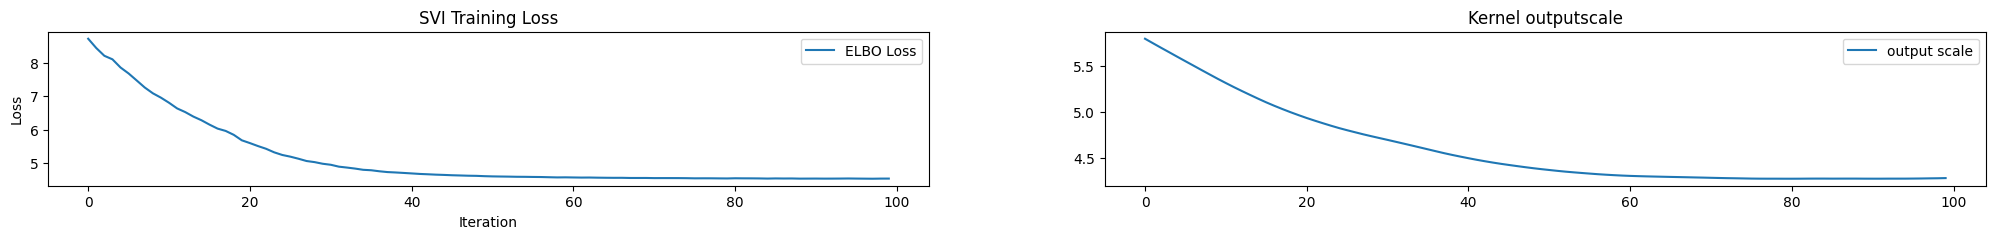

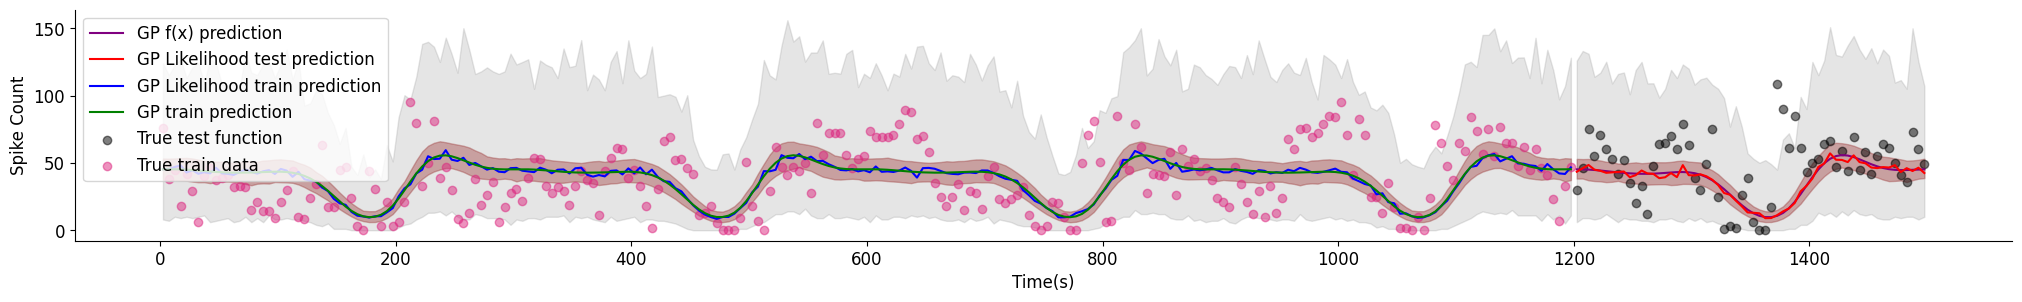

  0%|          | 0/100 [00:00<?, ?it/s]

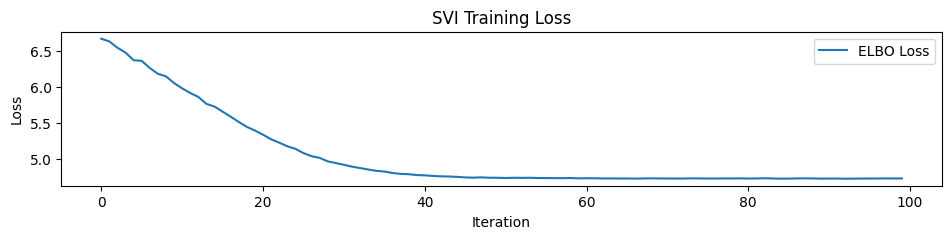

=== TRAIN DATA === === TEST DATA ===
Pseudo-R2: 0.0509    0.0544
lengthscale 0.7285 period_length 296.7591 outputscale 4.2799 w 0.7788 noise_prob 0.0100 ON_1
alpha_init:  1.1102230246251565e-16 output_scale_init:  tensor(0.6931, grad_fn=<SoftplusBackward0>)
initial scale: tensor(6.9723, grad_fn=<SoftplusBackward0>) sqrt tensor(2.6405, grad_fn=<SqrtBackward0>)


  0%|          | 0/100 [00:00<?, ?it/s]

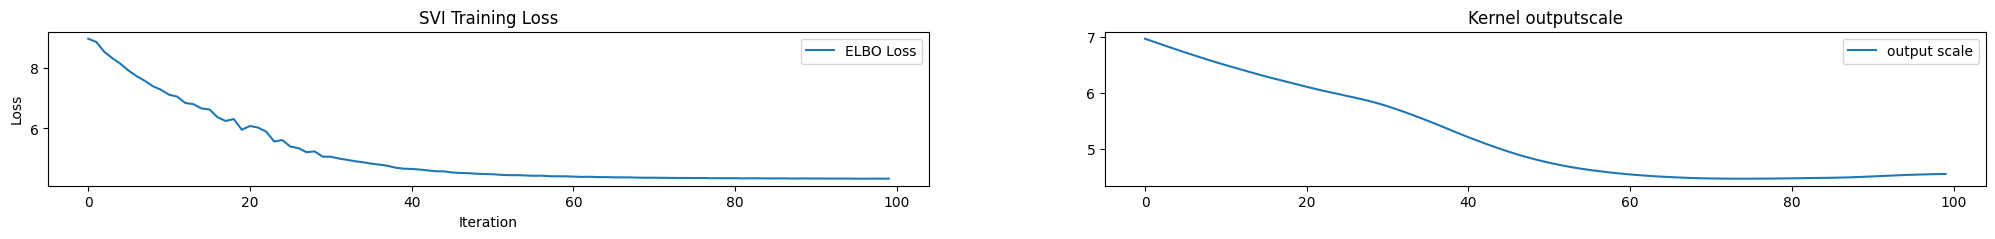

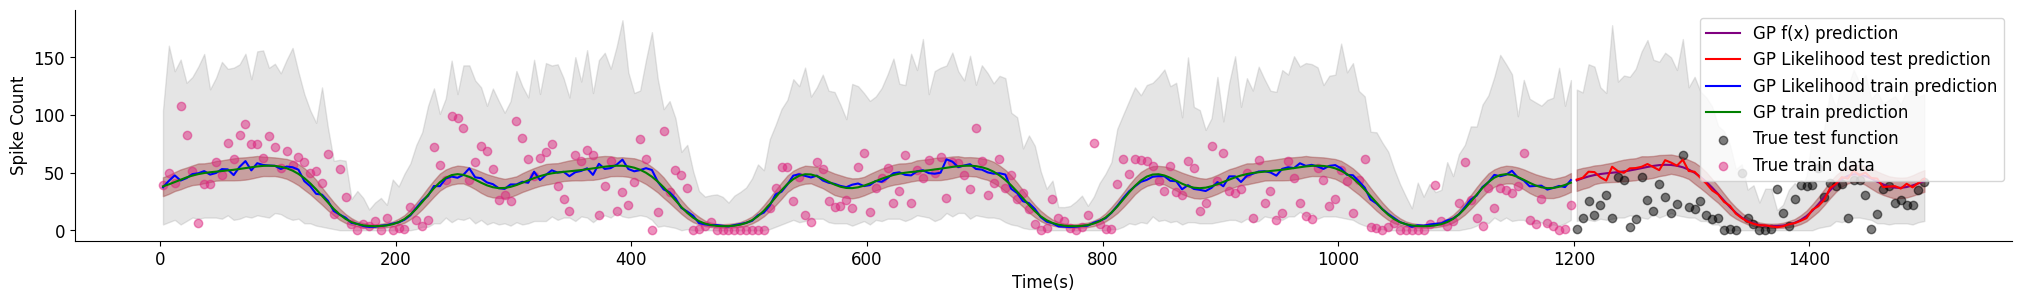

  0%|          | 0/100 [00:00<?, ?it/s]

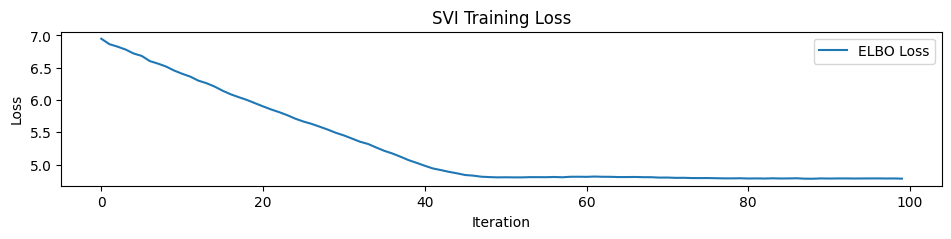

=== TRAIN DATA === === TEST DATA ===
Pseudo-R2: 0.1043    -0.0169
lengthscale 0.7354 period_length 296.5902 outputscale 4.5551 w 0.7895 noise_prob 0.0100 ON_2
alpha_init:  1.1102230246251565e-16 output_scale_init:  tensor(0.6931, grad_fn=<SoftplusBackward0>)
initial scale: tensor(26.2260, grad_fn=<SoftplusBackward0>) sqrt tensor(5.1211, grad_fn=<SqrtBackward0>)


  0%|          | 0/100 [00:00<?, ?it/s]

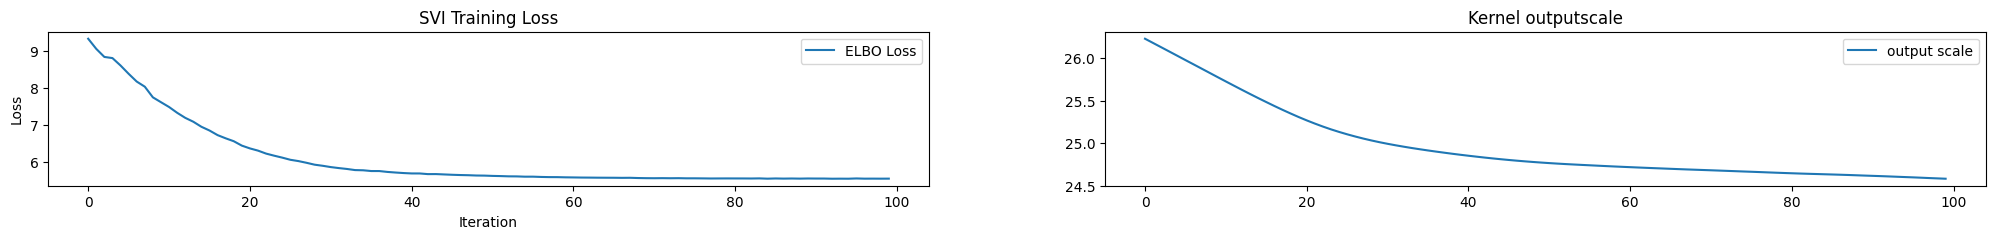

KeyboardInterrupt: 

In [28]:
fit_all_cells_and_return_params_fits(data, base_save_dir, num_iter=100,
                                        from_loaded=False, num_inducing =100,
                                        save_params=False,save_results=False,from_last=False,
                                        max_count=200,lr=0.05,compare_mean=True,cell_ids=None,model_mean=True,
                                        retrain_mean=False)

## Combined the Neutral and Neutral extra cells into one class

In [ ]:
with open(os.path.join(base_save_dir,"model_summary.csv")) as data_csv:
    combine_neutral_and_save(data_csv,
    output_path = os.path.join(base_save_dir,"combined_data.csv"))

Combined data saved to: results/gen_pois_no_exp/combined_data.csv


## Plot the Pseudo-R2 of the fits

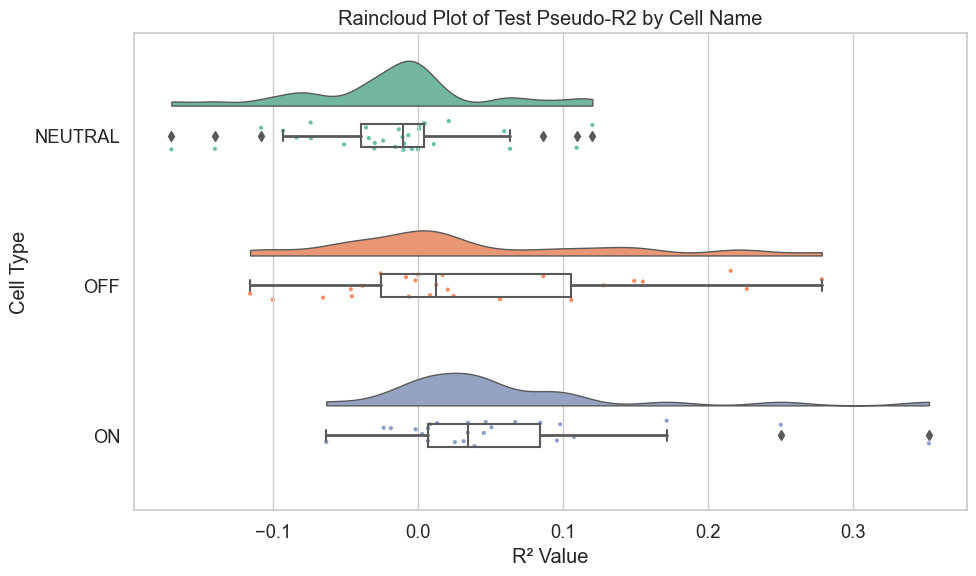

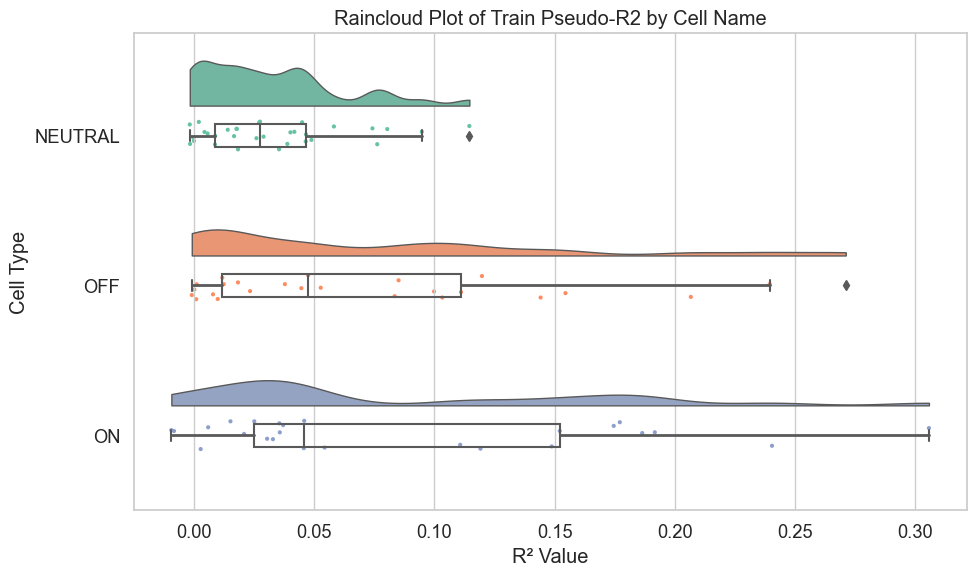

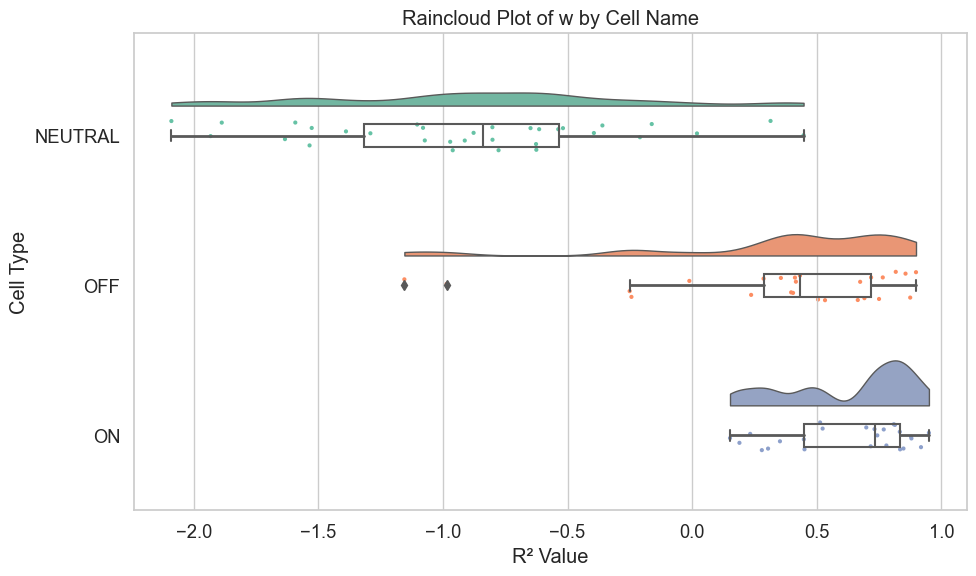

In [ ]:
with open(os.path.join(base_save_dir,"combined_data.csv")) as data_csv:
    df = pd.read_csv(data_csv)
    plot_rainclouds(data_csv,'Test Pseudo-R2',df)
    plot_rainclouds(data_csv,'Train Pseudo-R2',df)
    plot_rainclouds(data_csv,'w',df)

## Plot the Pseudo R2 of the fits on an interactive plot

In [ ]:
with open(os.path.join(base_save_dir,"combined_data.csv")) as data_csv:
    plot_interactive_raincloud(data_csv,'Test Pseudo-R2')